In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv('faithful.csv')

print(data.shape)
data.head()

(272, 2)


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [3]:
data.isnull().sum()

eruptions    0
 waiting     0
dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   eruptions  272 non-null    float64
 1    waiting   272 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 4.4 KB


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   eruptions  272 non-null    float64
 1    waiting   272 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 4.4 KB


In [8]:
# Clean column names
data.columns = data.columns.str.strip().str.lower()

print("Columns in dataset:")
print(data.columns.tolist())

Columns in dataset:
['eruptions', 'waiting']


In [9]:
# Use the two columns containing eruption duration and waiting time

x = data.iloc[:, :2].values

print("Shape:", x.shape)
print(x[:5])

Shape: (272, 2)
[[ 3.6   79.   ]
 [ 1.8   54.   ]
 [ 3.333 74.   ]
 [ 2.283 62.   ]
 [ 4.533 85.   ]]


In [10]:
sc = StandardScaler()

x_scaled = sc.fit_transform(x)

print(x_scaled[:5])

[[ 0.09849886  0.59712344]
 [-1.48145856 -1.24518118]
 [-0.13586149  0.22866251]
 [-1.05750332 -0.6556437 ]
 [ 0.91744345  1.03927655]]


In [11]:
wcss = []

In [12]:
for i in range(1, 11):

    model = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    model.fit(x_scaled)

    wcss.append(model.inertia_)

print(wcss)

[544.0, 79.575959488277, 56.313617740362595, 43.871262513430594, 34.27437919945956, 27.284261501679804, 23.845889371028548, 20.844788428977964, 18.75183118537031, 17.008147452621124]


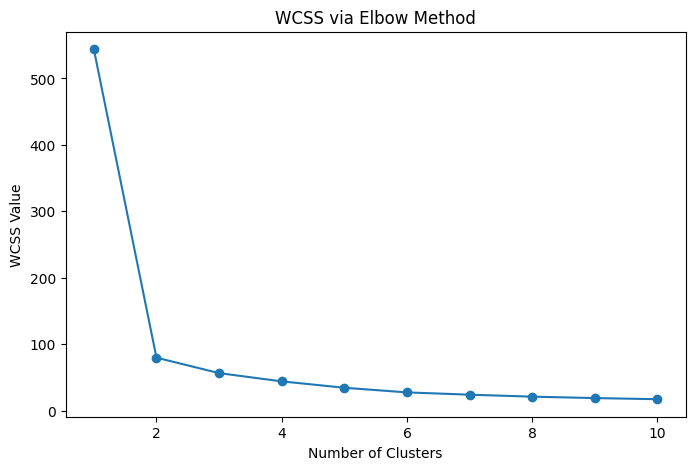

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.title('WCSS via Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Value')

plt.show()

In [14]:
model = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42,
    n_init=10
)

In [15]:
y_means = model.fit_predict(x_scaled)

print("Cluster labels:")
print(y_means)

Cluster labels:
[0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0
 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0]


In [16]:
print("Cluster Centers:")
print(model.cluster_centers_)

Cluster Centers:
[[ 0.70970327  0.67674488]
 [-1.26008539 -1.20156744]]


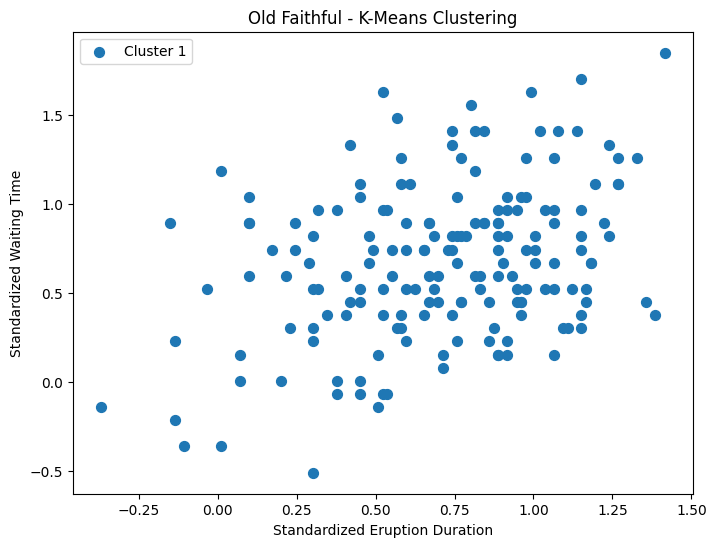

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    x_scaled[y_means == 0, 0],
    x_scaled[y_means == 0, 1],
    s=50,
    label='Cluster 1'
)

plt.xlabel('Standardized Eruption Duration')
plt.ylabel('Standardized Waiting Time')
plt.title('Old Faithful - K-Means Clustering')

plt.legend()
plt.show()

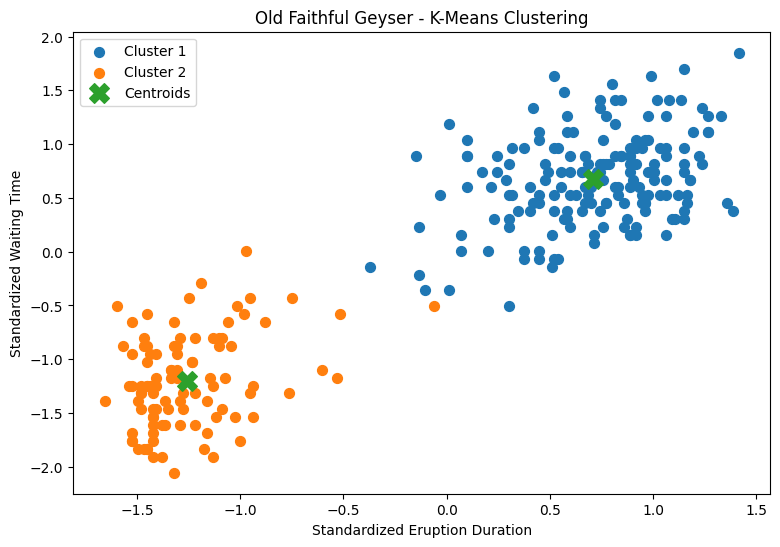

In [18]:
plt.figure(figsize=(9, 6))

for i in range(2):
    plt.scatter(
        x_scaled[y_means == i, 0],
        x_scaled[y_means == i, 1],
        s=50,
        label=f'Cluster {i + 1}'
    )

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel('Standardized Eruption Duration')
plt.ylabel('Standardized Waiting Time')
plt.title('Old Faithful Geyser - K-Means Clustering')

plt.legend()
plt.show()

In [19]:
data['Cluster'] = y_means

data.head()

,eruptions,waiting,Cluster
0,3.600,79,0
1,1.800,54,1
2,3.333,74,0
3,2.283,62,1
4,4.533,85,0


In [20]:
print(data['Cluster'].value_counts())

Cluster
0    174
1     98
Name: count, dtype: int64


In [21]:
cluster_summary = data.groupby('Cluster')[['eruptions', 'waiting']].mean()

print(cluster_summary)

         eruptions    waiting
Cluster                      
0         4.296328  80.080460
1         2.052204  54.591837
